# Predicting Aircraft Engine Failure Before It Happens
### PRT565 — Machine Learning, Artificial Intelligence and Algorithms · Assessment 3

| | |
|---|---|
| **Dataset** | NASA C-MAPSS Turbofan Engine Degradation Simulation, subset FD001 (Kaggle: `behrad3d/nasa-cmaps`) |
| **Task** | Binary classification: *will this engine fail within the next 30 operating cycles?* |
| **Machine learning models** | Decision Tree · Random Forest · Gaussian Naïve Bayes |
| **Deep learning models** | Multilayer ANN (MLP) · LSTM recurrent network |
| **Metrics** | Accuracy · Precision · Recall · F1-score · ROC-AUC · PR-AUC |

---

#### Contents
0. [Setup and data loading](#0.-Setup-and-data-loading)
1. [Problem and motivation](#1.-Problem-and-motivation)
2. [Dataset description and exploratory analysis](#2.-Dataset-description-and-exploratory-analysis)
3. [Building the target variable](#3.-Building-the-target-variable)
4. [Feature selection and feature engineering](#4.-Feature-selection-and-feature-engineering)
5. [Train / validation / test design](#5.-Train-/-validation-/-test-design)
6. [Machine learning models](#6.-Machine-learning-models)
7. [Deep learning models](#7.-Deep-learning-models)
8. [Final evaluation on the NASA test set](#8.-Final-evaluation-on-the-NASA-test-set)
9. [Conclusion](#9.-Conclusion)
10. [Limitations and future work](#10.-Limitations-and-future-work)
11. [References](#11.-References)

**Reproducibility.** Every random seed is fixed and TensorFlow runs in deterministic mode, so a re-run gives the same numbers. The notebook runs in Google Colab without changes, or locally with `pip install -r requirements.txt`.

---
# 0. Setup and data loading

In [1]:
import os, glob, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # silence TensorFlow start-up logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- consistent colours and plot style (every figure is exported for the slides) ----
PALETTE = {
    "Baseline (majority)": "#9a9a9a",
    "Decision Tree":       "#2a78d6",
    "Random Forest":       "#eb6834",
    "Naive Bayes":         "#1baf7a",
    "MLP (ANN)":           "#eda100",
    "LSTM":                "#c2477e",
}
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e3e2dd"
BLUE, ORANGE = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

def save(name):
    """Save the current figure at slide resolution."""
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}/{name}.png", bbox_inches="tight", facecolor="white")

print("Environment ready.")

Environment ready.


In [2]:
# ---- locate the data: local ./data folder first, otherwise download from Kaggle ----
DATA_DIR = "data"
if not os.path.exists(os.path.join(DATA_DIR, "train_FD001.txt")):
    import kagglehub                                   # public dataset, no API key needed
    path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
    DATA_DIR = os.path.dirname(glob.glob(os.path.join(path, "**", "train_FD001.txt"),
                                         recursive=True)[0])
print("Data directory:", DATA_DIR)

# Column layout is fixed by NASA: engine id, cycle, 3 operational settings, 21 sensors.
index_cols   = ["unit", "cycle"]
setting_cols = [f"setting_{i}" for i in (1, 2, 3)]
sensor_cols  = [f"s_{i}" for i in range(1, 22)]
COLS = index_cols + setting_cols + sensor_cols

def load(fname, names=COLS):
    return pd.read_csv(os.path.join(DATA_DIR, fname), sep=r"\s+",
                       header=None, names=names, index_col=False)

train    = load("train_FD001.txt")
test     = load("test_FD001.txt")
rul_true = load("RUL_FD001.txt", names=["RUL"])

print(f"train: {train.shape}   test: {test.shape}   RUL file: {rul_true.shape}")
print(f"engines: train = {train.unit.nunique()}, test = {test.unit.nunique()}")
train.head()

Data directory: data


train: (20631, 26)   test: (13096, 26)   RUL file: (100, 1)
engines: train = 100, test = 100


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


---
# 1. Problem and motivation

A commercial jet engine costs about as much as the aircraft it is mounted on. If it fails unplanned in service, the aircraft is grounded ("aircraft on ground", AOG), passengers are stranded and the engine has to be removed without notice. Maintenance planners face a trade-off with unequal costs on each side:

- **Service too early** and usable life is thrown away on a working engine.
- **Service too late** and the result is an unscheduled removal, AOG costs and a safety risk.

**Predictive maintenance** replaces fixed service intervals with a data-driven answer to one question: *given how this specific engine has behaved so far, is it about to fail?* We model that question as a binary classification task.

Because a **missed failure costs far more than a false alarm**, accuracy alone is the wrong yardstick. We report **recall**, **precision** and **F1** for the failure class, alongside accuracy and threshold-independent ROC-AUC and PR-AUC.

---
# 2. Dataset description and exploratory analysis

NASA's **C-MAPSS** (Commercial Modular Aero-Propulsion System Simulation) dataset simulates turbofan engine degradation at high fidelity (Saxena et al., 2008). It was released by the NASA Prognostics Center of Excellence and is the standard benchmark in the prognostics literature. We use subset **FD001**:

| Property | Value |
|---|---|
| Training engines | 100, each run **to failure** |
| Test engines | 100, each **cut off at some point before failure**; NASA supplies the true remaining life |
| Operating conditions | 1 (sea level) |
| Fault mode | 1 (High-Pressure Compressor degradation) |
| Columns per row | engine id, cycle, 3 operational settings, 21 sensors |

**Each row is one operating cycle of one engine.** Engines start healthy and degrade until they fail, so the data is a *multivariate time series per engine*, not a set of independent rows. That fact drives the splitting, the feature engineering and the choice of an LSTM later on.

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit       20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   s_1        20631 non-null  float64
 6   s_2        20631 non-null  float64
 7   s_3        20631 non-null  float64
 8   s_4        20631 non-null  float64
 9   s_5        20631 non-null  float64
 10  s_6        20631 non-null  float64
 11  s_7        20631 non-null  float64
 12  s_8        20631 non-null  float64
 13  s_9        20631 non-null  float64
 14  s_10       20631 non-null  float64
 15  s_11       20631 non-null  float64
 16  s_12       20631 non-null  float64
 17  s_13       20631 non-null  float64
 18  s_14       20631 non-null  float64
 19  s_15       20631 non-null  float64
 20  s_16       20631 

In [4]:
summary = train[setting_cols + sensor_cols].agg(["mean", "std", "min", "max", "nunique"]).T
summary.round(4)

,mean,std,min,max,nunique
setting_1,-0.0000,0.0022,-0.0087,0.0087,158.0
setting_2,0.0000,0.0003,-0.0006,0.0006,13.0
setting_3,100.0000,0.0000,100.0000,100.0000,1.0
s_1,518.6700,0.0000,518.6700,518.6700,1.0
s_2,642.6809,0.5001,641.2100,644.5300,310.0
s_3,1590.5231,6.1311,1571.0400,1616.9100,3012.0
s_4,1408.9338,9.0006,1382.2500,1441.4900,4051.0
s_5,14.6200,0.0000,14.6200,14.6200,1.0
s_6,21.6098,0.0014,21.6000,21.6100,2.0
s_7,553.3677,0.8851,549.8500,556.0600,513.0


**Univariate check (data analysis).** The `std` and `nunique` columns already show that several sensors barely change, or never change at all, across the whole training set. A feature that does not vary cannot tell two classes apart, so these are removed in Section 4.

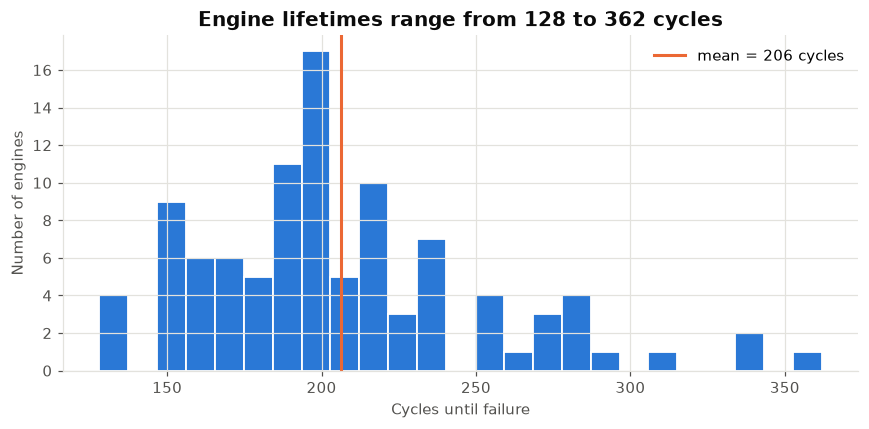

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0

Longest-lived engine lasts 2.8x as long as the shortest-lived one.


In [5]:
# ---- how long does an engine live? --------------------------------------------------
life = train.groupby("unit")["cycle"].max()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(life, bins=25, color=BLUE, edgecolor="white", linewidth=1.2)
ax.axvline(life.mean(), color=ORANGE, linewidth=2, label=f"mean = {life.mean():.0f} cycles")
ax.set_xlabel("Cycles until failure")
ax.set_ylabel("Number of engines")
ax.set_title(f"Engine lifetimes range from {life.min()} to {life.max()} cycles")
ax.legend()
save("01_engine_lifetimes")
plt.show()

print(life.describe().round(1).to_string())
print(f"\nLongest-lived engine lasts {life.max() / life.min():.1f}x as long as the shortest-lived one.")

Lifetimes vary a lot between engines. A fixed maintenance interval has to be set for the *weakest* engine, so most engines are serviced with much of their life unused. That gap is the value predictive maintenance tries to recover.

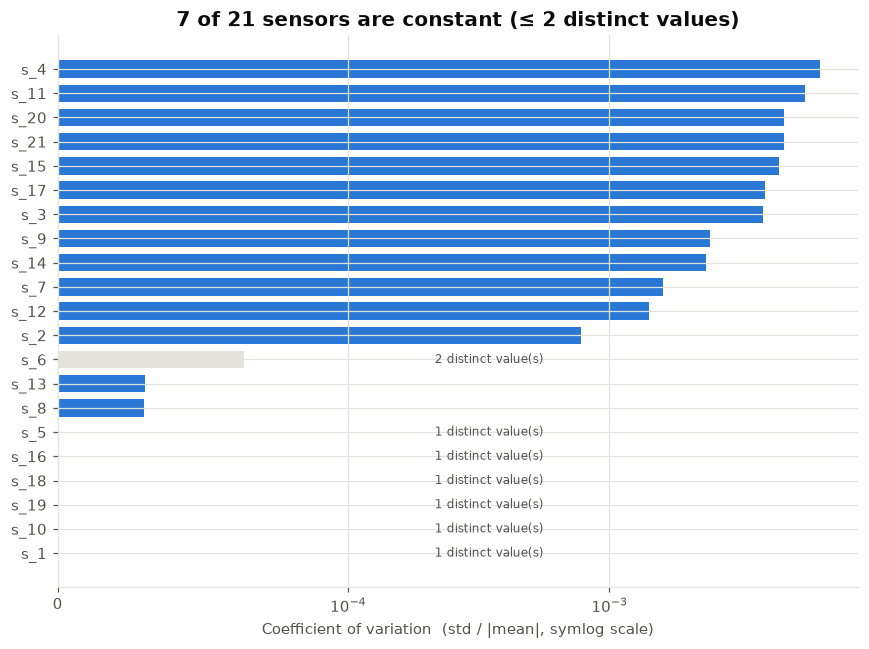

Constant / near-constant columns: ['setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']


In [6]:
# ---- which columns actually vary? -----------------------------------------------------
nunique  = train[setting_cols + sensor_cols].nunique()
constant = nunique[nunique <= 2].index.tolist()          # never / almost never changes

# (operational settings are discussed in Section 4.1 — their mean is ~0, so a CV is meaningless)
cv = (train[sensor_cols].std() / train[sensor_cols].mean().abs()).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [GRID if c in constant else BLUE for c in cv.index]
ax.barh(cv.index, cv.values, color=colors, height=0.72)
ax.set_xscale("symlog", linthresh=1e-4)
ax.set_xlabel("Coefficient of variation  (std / |mean|, symlog scale)")
n_const_sensors = sum(c in sensor_cols for c in constant)
ax.set_title(f"{n_const_sensors} of 21 sensors are constant (≤ 2 distinct values)")
for i, c in enumerate(cv.index):
    if c in constant:
        ax.text(2e-4, i, f"  {nunique[c]} distinct value(s)", va="center", fontsize=8, color=INK_SOFT)
save("02_sensor_variability")
plt.show()

print("Constant / near-constant columns:", constant)

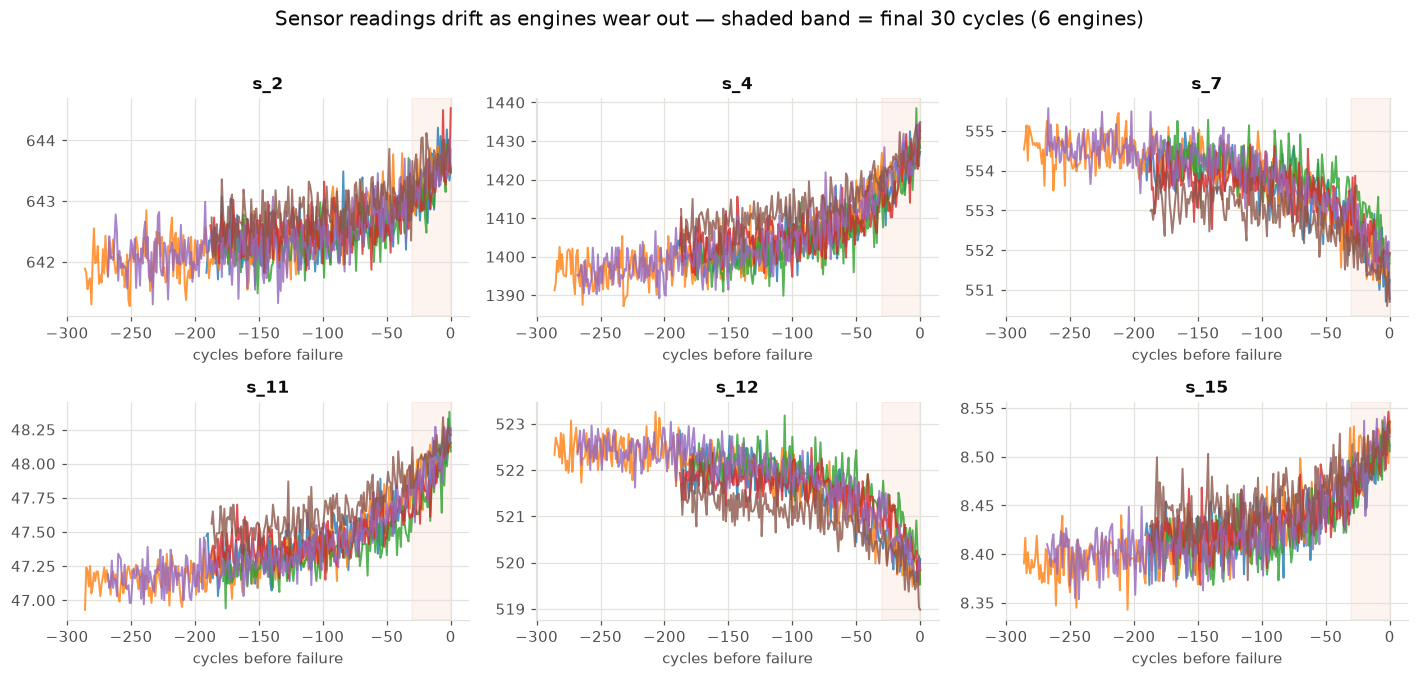

In [7]:
# ---- degradation trajectories, aligned at the moment of failure -----------------------
watch = ["s_2", "s_4", "s_7", "s_11", "s_12", "s_15"]
sample_units = [1, 2, 3, 4, 5, 6]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, s in zip(axes.ravel(), watch):
    for u in sample_units:
        g = train[train.unit == u]
        ax.plot(g.cycle - g.cycle.max(), g[s], linewidth=1.3, alpha=0.8)
    ax.axvspan(-30, 0, color=ORANGE, alpha=0.08)
    ax.set_title(s, fontsize=11)
    ax.set_xlabel("cycles before failure")
fig.suptitle("Sensor readings drift as engines wear out — shaded band = final 30 cycles "
             f"({len(sample_units)} engines)", fontsize=13, y=1.02, color=INK)
save("03_degradation_trajectories")
plt.show()

Each line is one engine, lined up at the moment it failed (x = 0). Every sensor drifts in a steady direction as the engine ages, and the drift **speeds up near the end of life**. The information is in the **trajectory**, not in any single reading, and engines start from different baselines. Two design decisions follow from this plot:
1. Give the row-based models features that describe *change over time* (Section 4.2).
2. Test a sequence model (LSTM) that can learn the trajectory directly (Section 7.2).

---
# 3. Building the target variable

The raw data has no label, but it does have time. For each training engine we know the cycle at which it failed, so the **Remaining Useful Life (RUL)** at any cycle is

$$\text{RUL} = \text{failure cycle} - \text{current cycle}.$$

For the test engines, NASA gives the true RUL at the **last observed** cycle. So for every earlier cycle, $\text{RUL} = (\text{last cycle} - \text{cycle}) + \text{RUL}_{\text{last}}$.

We turn RUL into the binary target:

$$y = \begin{cases} 1 & \text{if RUL} \le 30 \quad \text{(failure imminent — schedule maintenance)}\\ 0 & \text{otherwise (healthy)}\end{cases}$$

A 30-cycle horizon is common in the C-MAPSS literature. It is long enough to book a maintenance slot and short enough that the warning is still actionable.

In [8]:
W = 30   # failure horizon, in cycles

# ---- training labels: engines run to failure ----------------------------------------
train["RUL"]   = train.groupby("unit")["cycle"].transform("max") - train["cycle"]
train["label"] = (train["RUL"] <= W).astype(int)

# ---- test labels: engines truncated; NASA gives RUL at the final observed cycle -----
last_cycle = test.groupby("unit")["cycle"].transform("max")
rul_at_end = test["unit"].map(dict(zip(range(1, len(rul_true) + 1), rul_true["RUL"])))
test["RUL"]   = last_cycle - test["cycle"] + rul_at_end
test["label"] = (test["RUL"] <= W).astype(int)

print(f"Failure-within-{W} share — train rows: {train.label.mean():.1%}   test rows: {test.label.mean():.1%}")
train[["unit", "cycle", "s_2", "s_11", "RUL", "label"]].head()

Failure-within-30 share — train rows: 15.0%   test rows: 2.5%


,unit,cycle,s_2,s_11,RUL,label
0,1,1,641.82,47.47,191,0
1,1,2,642.15,47.49,190,0
2,1,3,642.35,47.27,189,0
3,1,4,642.35,47.13,188,0
4,1,5,642.37,47.28,187,0


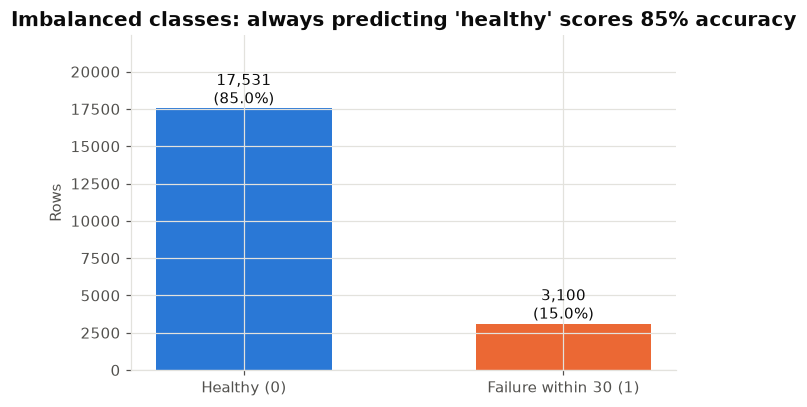

In [9]:
# ---- class balance -------------------------------------------------------------------
counts = train.label.value_counts().sort_index()
majority_acc = counts.max() / counts.sum()

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(["Healthy (0)", f"Failure within {W} (1)"], counts.values,
              color=[BLUE, ORANGE], width=0.55)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / counts.sum():.1%})",
            ha="center", va="bottom", fontsize=10, color=INK)
ax.set_ylabel("Rows")
ax.set_ylim(0, counts.max() * 1.28)
ax.set_title(f"Imbalanced classes: always predicting 'healthy' scores {majority_acc:.0%} accuracy")
save("04_class_balance")
plt.show()

**Evaluation metrics.** Only about one row in seven is a failure warning. A model that always says "healthy" gets the accuracy shown above and **never catches a single failure**. So our results tables lead with **recall** (what share of real failures we catch), **precision** (what share of alarms are real) and their harmonic mean **F1**. We also add a majority-class baseline to every table, to show in the numbers that accuracy is misleading here.

---
# 4. Feature selection and feature engineering

## 4.1 Feature selection
We use two filters, and each one is justified by the data:
1. **Constant columns are dropped.** A column with at most two distinct values over about 20,000 rows carries no information.
2. **Operational settings are dropped.** FD001 has one operating condition, so `setting_1` and `setting_2` are tiny noise around that condition. The check below shows that they are essentially uncorrelated with RUL.

In [10]:
useful  = [c for c in sensor_cols if c not in constant]
dropped = [c for c in setting_cols + sensor_cols if c not in useful]

print(f"Dropped {len(dropped)} columns: {dropped}")
print(f"Kept {len(useful)} informative sensors: {useful}\n")
print("Correlation of the operational settings with RUL:")
print(train[["setting_1", "setting_2", "RUL"]].corr()["RUL"].drop("RUL").round(3).to_string())

Dropped 10 columns: ['setting_1', 'setting_2', 'setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
Kept 14 informative sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

Correlation of the operational settings with RUL:
setting_1   -0.003
setting_2   -0.002


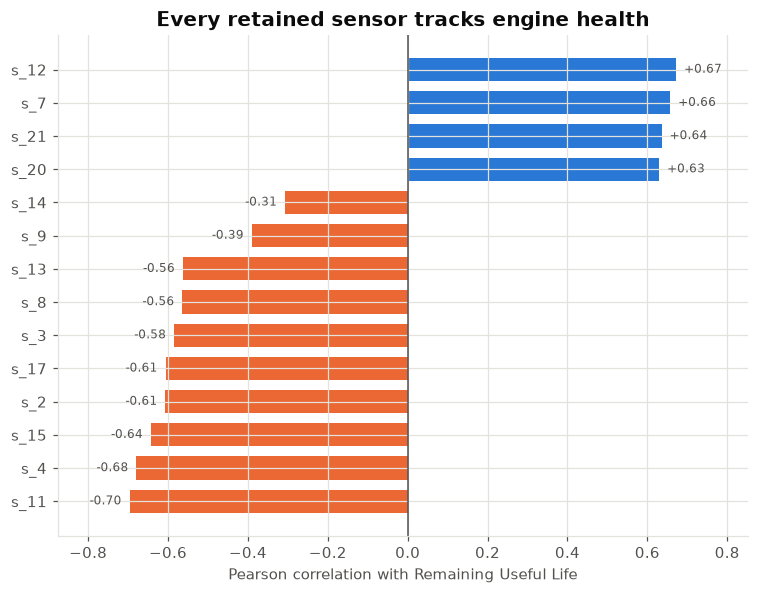

In [11]:
# ---- correlation of the retained sensors with RUL ------------------------------------
corr = train[useful + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(corr.index, corr.values, color=[ORANGE if v < 0 else BLUE for v in corr.values], height=0.7)
ax.axvline(0, color=INK_SOFT, linewidth=1)
ax.set_xlabel("Pearson correlation with Remaining Useful Life")
ax.set_title("Every retained sensor tracks engine health")
for i, v in enumerate(corr.values):
    ax.text(v + (0.02 if v > 0 else -0.02), i, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=8, color=INK_SOFT)
ax.set_xlim(corr.min() - 0.18, corr.max() + 0.18)
save("05_sensor_rul_correlation")
plt.show()

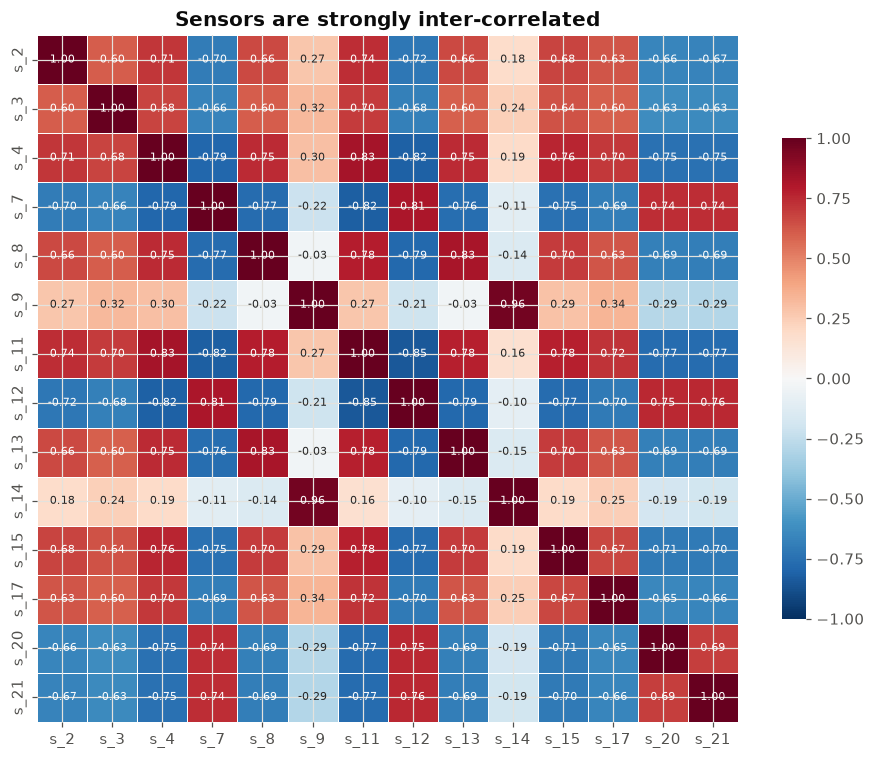

Mean |correlation| between sensor pairs: 0.58
Pairs with |r| > 0.7: 38 of 91


In [12]:
# ---- how correlated are the sensors with EACH OTHER? (evidence for the Naive Bayes discussion)
sensor_corr = train[useful].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(sensor_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Sensors are strongly inter-correlated")
save("06_sensor_correlation_matrix")
plt.show()

off_diag = sensor_corr.abs().values[np.triu_indices(len(useful), k=1)]
print(f"Mean |correlation| between sensor pairs: {off_diag.mean():.2f}")
print(f"Pairs with |r| > 0.7: {(off_diag > 0.7).sum()} of {len(off_diag)}")

Many sensor pairs are strongly correlated because they measure the same underlying degradation. This matters for **Naïve Bayes**, which assumes features are conditionally independent given the class. We come back to this in Section 6.4.

## 4.2 Feature engineering — giving row-based models a sense of time

Decision Trees, Random Forests, Naïve Bayes and the MLP see **one row at a time**. They do not know that cycle 200 of engine 7 came right after cycle 199. So we build features that encode *change over time*, always computed **within each engine** and using **only past and current cycles**. Nothing from the future is used, so the features can be computed on a live engine.

| Feature | Meaning |
|---|---|
| `<sensor>_rmean` | rolling mean over the last 20 cycles — smooths sensor noise |
| `<sensor>_rstd`  | rolling standard deviation over the last 20 cycles — readings become less stable as the engine degrades |
| `<sensor>_delta` | current value minus this engine's **first** reading — drift from its own healthy baseline |
| `cycle` | age of the engine in cycles — known at prediction time, so it is a legitimate feature |

`_delta` compares each engine with itself, which removes the between-engine baseline differences seen in Section 2. this is the same idea as `FamilySize = SibSp + Parch + 1` in the Titanic notebook: new columns that carry more signal than the originals. Here we combine each sensor with its own history.

In [13]:
ROLL = 20   # rolling window, in cycles

def engineer(df, sensors, win=ROLL):
    """Add rolling mean, rolling std and drift-from-baseline features, computed PER ENGINE
    using only the current and past cycles (no look-ahead)."""
    df = df.sort_values(["unit", "cycle"]).copy()
    g = df.groupby("unit")[sensors]

    rmean = g.rolling(win, min_periods=1).mean().reset_index(level=0, drop=True)
    rstd  = g.rolling(win, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)
    rmean.columns = [f"{c}_rmean" for c in sensors]
    rstd.columns  = [f"{c}_rstd" for c in sensors]

    delta = df[sensors] - g.transform("first")
    delta.columns = [f"{c}_delta" for c in sensors]

    return pd.concat([df, rmean, rstd, delta], axis=1)

train_f = engineer(train, useful)
test_f  = engineer(test, useful)

FEATURES = (useful
            + [f"{c}_rmean" for c in useful]
            + [f"{c}_rstd" for c in useful]
            + [f"{c}_delta" for c in useful]
            + ["cycle"])

print(f"{len(useful)} raw sensors  ->  {len(FEATURES)} model features")
train_f.loc[train_f.unit == 1, ["unit", "cycle", "s_4", "s_4_rmean", "s_4_rstd", "s_4_delta", "label"]].iloc[18:24]

14 raw sensors  ->  57 model features


,unit,cycle,s_4,s_4_rmean,s_4_rstd,s_4_delta,label
18,1,19,1400.35,1400.643684,2.786753,-0.25,0
19,1,20,1405.23,1400.873000,2.899822,4.63,0
20,1,21,1398.13,1400.749500,2.963949,-2.47,0
21,1,22,1400.57,1400.621000,2.910077,-0.03,0
22,1,23,1394.75,1400.148500,3.061619,-5.85,0
23,1,24,1398.81,1399.995500,3.047488,-1.79,0


---
# 5. Train / validation / test design

**Data leakage.** A random `train_test_split` would put cycle 100 of engine 7 in training and cycle 101 of the same engine in testing. Neighbouring cycles are almost identical, so the model would be tested on data it had effectively memorised, and the scores would be inflated. We therefore split **by engine**, which matches deployment: a live model always meets engines it has never seen.

| Set | Engines | Role |
|---|---|---|
| **Train** | 75 of the 100 run-to-failure engines | fitting models and cross-validated tuning (`GroupKFold`) |
| **Validation** | the other 25 run-to-failure engines | early stopping for the neural networks and comparing models |
| **Test** | NASA's 100 separate test engines | **final, untouched evaluation** — the headline results |

**Same rows for every model.** The LSTM needs a 30-cycle window of history, so it cannot predict before an engine's 30th cycle. To keep the comparison exactly fair, **all models are scored on the same rows: cycles ≥ 30 of each validation and test engine.**

**Scaling.** Scalers are fit on the **training engines only** and then applied to validation and test. Fitting them on everything would leak the distribution of the held-out data into training.

In [14]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler

SEQ_LEN = 30   # history window for the LSTM, and the first cycle at which every model is scored

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
tr_idx, va_idx = next(gss.split(train_f, train_f["label"], groups=train_f["unit"]))
tr = train_f.iloc[tr_idx].sort_values(["unit", "cycle"]).copy()
va = train_f.iloc[va_idx].sort_values(["unit", "cycle"]).copy()
te = test_f.sort_values(["unit", "cycle"]).copy()

assert not set(tr.unit) & set(va.unit), "LEAKAGE: an engine appears in both train and validation"

# evaluation rows: identical for all six models
va_eval = va[va.cycle >= SEQ_LEN].copy()
te_eval = te[te.cycle >= SEQ_LEN].copy()

scaler = StandardScaler().fit(tr[FEATURES])            # fit on TRAINING engines only
X_tr, y_tr = scaler.transform(tr[FEATURES]),      tr["label"].to_numpy()
X_va, y_va = scaler.transform(va_eval[FEATURES]), va_eval["label"].to_numpy()
X_te, y_te = scaler.transform(te_eval[FEATURES]), te_eval["label"].to_numpy()

split_summary = pd.DataFrame({
    "engines":  [tr.unit.nunique(), va_eval.unit.nunique(), te_eval.unit.nunique()],
    "rows":     [len(X_tr), len(X_va), len(X_te)],
    "failure share": [y_tr.mean(), y_va.mean(), y_te.mean()],
}, index=["train", "validation (cycle ≥ 30)", "test (cycle ≥ 30)"])
print("No engine overlap between train and validation — split is leak-free.")
split_summary.style.format({"rows": "{:,}", "failure share": "{:.1%}"})

No engine overlap between train and validation — split is leak-free.


,engines,rows,failure share
train,75,"15,569",14.9%
validation (cycle ≥ 30),25,"4,337",17.9%
test (cycle ≥ 30),100,"10,196",3.3%


## 5.1 A shared scoreboard
Every model is scored by the same function, using its **predicted probability** of failure and a threshold of 0.5. That keeps the comparison consistent and also gives us the threshold-independent ROC-AUC and PR-AUC.

In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

METRICS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
RESULTS = {"validation": {}, "test": {}}
PROBS   = {"validation": {}, "test": {}}

def evaluate(name, split, y_true, y_prob, threshold=0.5):
    """Score one model on one split and remember the probabilities for later plots."""
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)
    RESULTS[split][name] = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
        "PR-AUC":    average_precision_score(y_true, y_prob),
    }
    PROBS[split][name] = (y_true, y_prob)
    return pd.DataFrame(RESULTS[split][name], index=[f"{name} — {split}"]).round(4)

def plot_confusion(name, split, ax):
    y_true, y_prob = PROBS[split][name]
    cm = confusion_matrix(y_true, (y_prob >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                linewidths=1.5, linecolor="white", annot_kws={"size": 11},
                xticklabels=["Healthy", "Failure"], yticklabels=["Healthy", "Failure"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(name, fontsize=11)
    ax.grid(False)

---
# 6. Machine learning models

## 6.1 Baseline — always predict the majority class
A `DummyClassifier` that always predicts "healthy". Any real model has to beat it on recall and F1, not just on accuracy.

In [16]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
evaluate("Baseline (majority)", "validation", y_va, baseline.predict_proba(X_va)[:, 1])

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (majority) — validation,0.8213,0.0,0.0,0.0,0.5,0.1787


## 6.2 Decision Tree

`criterion="entropy"` makes the tree choose splits by **Information Gain**, as calculated by hand (Quinlan, 1986). `max_depth` and `min_samples_leaf` are **pre-pruning** controls against overfitting. `class_weight="balanced"` makes a missed failure cost more than a false alarm during training, which addresses the class imbalance.

**Tuning without leakage.** We pick the pruning parameters with a small grid search. It uses 5-fold **`GroupKFold`** on the training engines, so each fold holds out whole engines, and it is scored on F1. The validation and test engines play no part in tuning.

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, GroupKFold

cv5 = GroupKFold(n_splits=5)

dt_search = GridSearchCV(
    DecisionTreeClassifier(criterion="entropy", class_weight="balanced", random_state=RANDOM_STATE),
    param_grid={"max_depth": [4, 6, 8, 10, 12, 16, 20], "min_samples_leaf": [10, 25, 50, 100]},
    scoring="f1", cv=cv5, n_jobs=-1)
dt_search.fit(X_tr, y_tr, groups=tr["unit"])
dt = dt_search.best_estimator_

print("Best parameters:", dt_search.best_params_, f"  (CV F1 = {dt_search.best_score_:.3f})")
pd.DataFrame(dt_search.cv_results_).pivot_table(
    index="param_max_depth", columns="param_min_samples_leaf", values="mean_test_score").round(3)

Best parameters: {'max_depth': 12, 'min_samples_leaf': 10}   (CV F1 = 0.841)


param_min_samples_leaf,10,25,50,100
param_max_depth,,,,
4,0.817,0.815,0.815,0.812
6,0.827,0.827,0.831,0.818
8,0.833,0.825,0.830,0.815
10,0.839,0.823,0.820,0.815
12,0.841,0.823,0.820,0.815
16,0.841,0.823,0.820,0.815
20,0.841,0.823,0.820,0.815


In [18]:
evaluate("Decision Tree", "validation", y_va, dt.predict_proba(X_va)[:, 1])

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Decision Tree — validation,0.9294,0.7711,0.8606,0.8134,0.9235,0.797


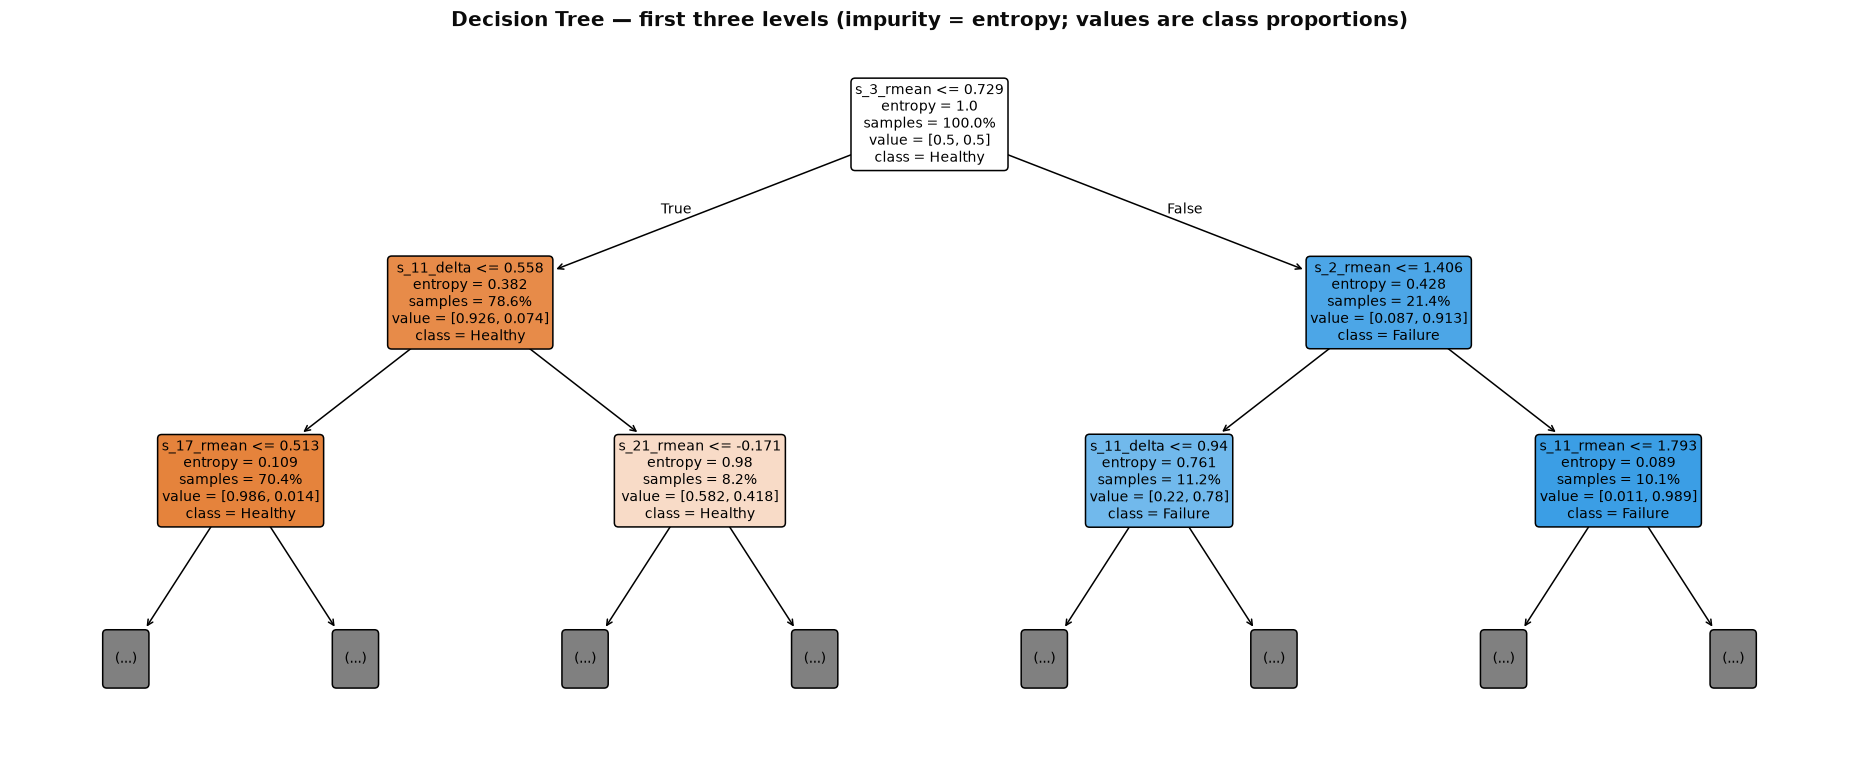

In [19]:
# ---- the top of the tree: rules a maintenance engineer can read ------------------------
fig, ax = plt.subplots(figsize=(17, 7))
plot_tree(dt, max_depth=2, feature_names=FEATURES, class_names=["Healthy", "Failure"],
          filled=True, rounded=True, fontsize=9, impurity=True, proportion=True, ax=ax)
ax.set_title("Decision Tree — first three levels (impurity = entropy; values are class proportions)",
             fontsize=13)
save("07_decision_tree_top")
plt.show()

*How to read it:* thresholds are in **standardised units** (0 = the training mean, 1 = one standard deviation above it). The root shows a 50/50 class split only because `class_weight="balanced"` re-weights the rare failure rows.

The tree's biggest strength is **interpretability**. Each path from the root to a leaf is an if-then rule on named sensor features, the kind of rule that could go into a maintenance manual. The other models in this study cannot offer that directly.

## 6.3 Random Forest

A single tree is unstable: small changes in the data can produce a very different tree. A Random Forest (Breiman, 2001) averages many trees that are kept *decorrelated* by **bootstrapping**, where each tree sees a random resample of the rows, and by **feature randomness**, where each split considers only a random subset of the columns. The majority vote generalises better than any single tree. Tuning uses the same leak-free `GroupKFold` search.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_search = GridSearchCV(
    RandomForestClassifier(n_estimators=200, max_features="sqrt", class_weight="balanced",
                           n_jobs=-1, random_state=RANDOM_STATE),
    param_grid={"max_depth": [8, 14, None], "min_samples_leaf": [1, 5, 20]},
    scoring="f1", cv=cv5, n_jobs=1)
rf_search.fit(X_tr, y_tr, groups=tr["unit"])
rf = rf_search.best_estimator_

print("Best parameters:", rf_search.best_params_, f"  (CV F1 = {rf_search.best_score_:.3f})")
evaluate("Random Forest", "validation", y_va, rf.predict_proba(X_va)[:, 1])

Best parameters: {'max_depth': None, 'min_samples_leaf': 1}   (CV F1 = 0.901)


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random Forest — validation,0.968,0.9036,0.9187,0.9111,0.9935,0.9719


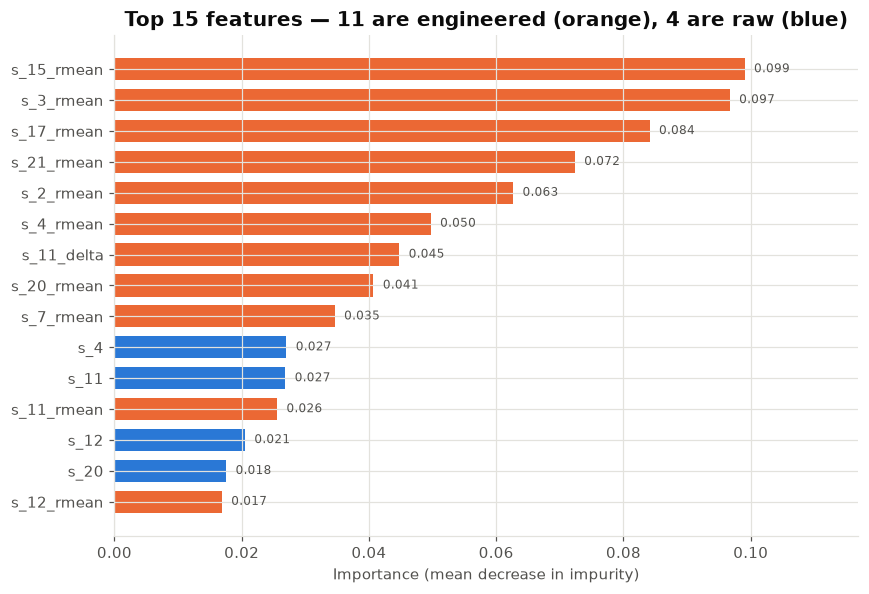

Engineered features hold 82% of the forest's total importance (they are 42 of 57 features).


In [21]:
# ---- which features does the forest rely on? ------------------------------------------
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
top = imp[:15]
is_eng = top.index.str.endswith(("_rmean", "_rstd", "_delta"))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.index[::-1], top.values[::-1],
        color=[ORANGE if e else BLUE for e in is_eng[::-1]], height=0.72)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title(f"Top 15 features — {is_eng.sum()} are engineered (orange), "
             f"{(~is_eng).sum()} are raw (blue)")
for i, v in enumerate(top.values[::-1]):
    ax.text(v + top.max() * 0.015, i, f"{v:.3f}", va="center", fontsize=8, color=INK_SOFT)
ax.set_xlim(0, top.max() * 1.18)
save("08_rf_feature_importance")
plt.show()

share_eng = imp[imp.index.str.endswith(("_rmean", "_rstd", "_delta"))].sum()
print(f"Engineered features hold {share_eng:.0%} of the forest's total importance "
      f"(they are {3 * len(useful)} of {len(FEATURES)} features).")

## 6.4 Gaussian Naïve Bayes

Naïve Bayes applies Bayes' theorem with a strong simplifying assumption: given the class, every feature is **independent** of every other. Section 4.1 showed that our sensors are strongly inter-correlated. Our engineered features make this worse, because the rolling mean and raw value of the same sensor are almost the same number. So the assumption is clearly violated here, and we look at what that does in practice. Naïve Bayes has no hyperparameters that need tuning.

In [22]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB().fit(X_tr, y_tr)
evaluate("Naive Bayes", "validation", y_va, nb.predict_proba(X_va)[:, 1])

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Naive Bayes — validation,0.9306,0.7261,0.9819,0.8349,0.9836,0.88


Share of validation predictions with probability < 1% or > 99%:
  Naive Bayes   : 98.1%
  Random Forest : 64.4%


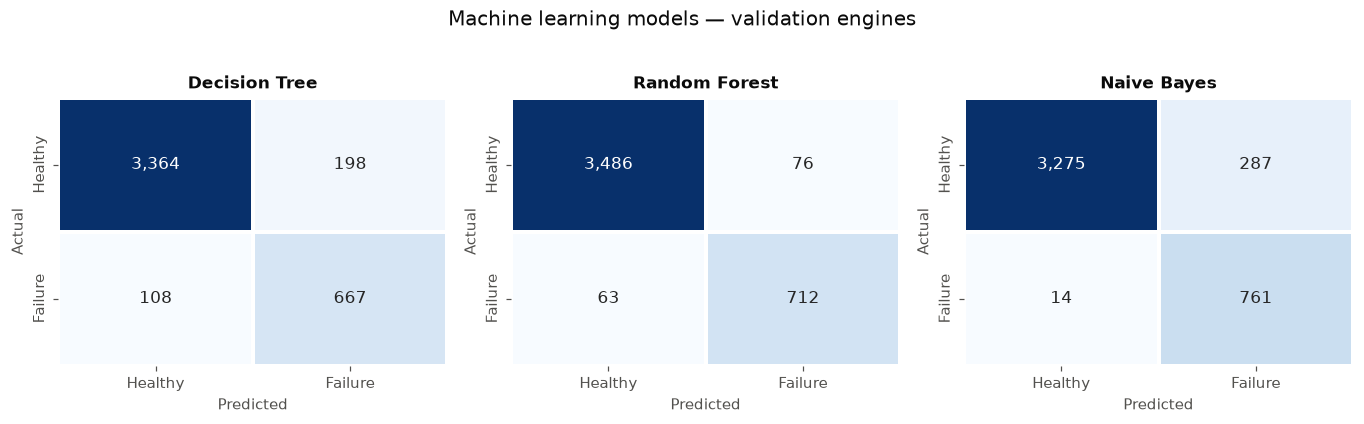

In [23]:
# ---- evidence of the independence assumption failing: over-confident probabilities --------
def extreme_share(p):
    return np.mean((p < 0.01) | (p > 0.99))

p_nb, p_rf = nb.predict_proba(X_va)[:, 1], rf.predict_proba(X_va)[:, 1]
print(f"Share of validation predictions with probability < 1% or > 99%:")
print(f"  Naive Bayes   : {extreme_share(p_nb):.1%}")
print(f"  Random Forest : {extreme_share(p_rf):.1%}")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))
for ax, name in zip(axes, ["Decision Tree", "Random Forest", "Naive Bayes"]):
    plot_confusion(name, "validation", ax)
fig.suptitle("Machine learning models — validation engines", fontsize=13, y=1.03, color=INK)
save("09_confusion_classical")
plt.show()

**Why Naïve Bayes behaves this way.** When features are correlated, Naïve Bayes multiplies what is really *the same evidence* many times over, as if each sensor were an independent witness. The result is **over-confident probabilities** pushed to 0 or 1, as the extreme-probability share above shows. Any error it makes is therefore made with near-certainty. We could predict this weakness from the model's assumptions before training it, and the confusion matrix confirms it.

---
# 7. Deep learning models

## 7.1 Multilayer Artificial Neural Network (MLP)

The **perceptron** from computes a weighted sum plus a bias and passes it through a threshold. ADALINE replaced the step with a continuous output so that the error could be minimised by **gradient descent**. A multilayer ANN stacks these units in layers. Each hidden neuron computes a weighted sum followed by a non-linear **ReLU** activation, and the output neuron uses a **sigmoid** to give a failure probability. The network is trained by back-propagation with the Adam optimiser on **binary cross-entropy**.

Regularisation against overfitting:
- **Dropout** randomly switches off neurons during training.
- **Early stopping** watches the loss on the *validation engines* and keeps the best weights.
- **Class weights** make each rare failure row count more in the loss.

In [24]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel("ERROR")

keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()        # identical results on every run
print("TensorFlow", tf.__version__)

mlp = keras.Sequential([
    keras.layers.Input(shape=(X_tr.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
], name="MLP_ANN")

mlp.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
            metrics=["accuracy"])
mlp.summary()

TensorFlow 2.21.0


Model: "MLP_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Class weights: each failure row counts (n_healthy / n_failure) times in the loss
cw = {0: 1.0, 1: float((y_tr == 0).sum() / (y_tr == 1).sum())}
print("Class weights:", {k: round(v, 2) for k, v in cw.items()})

hist_mlp = mlp.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                   epochs=100, batch_size=256, class_weight=cw, verbose=0, shuffle=True,
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                                            restore_best_weights=True)])
best_ep = int(np.argmin(hist_mlp.history["val_loss"])) + 1
print(f"Trained {len(hist_mlp.history['loss'])} epochs; best validation loss at epoch {best_ep}.")

evaluate("MLP (ANN)", "validation", y_va, mlp.predict(X_va, verbose=0).ravel())

Class weights: {0: 1.0, 1: 5.7}


Trained 16 epochs; best validation loss at epoch 6.


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
MLP (ANN) — validation,0.965,0.8643,0.9535,0.9067,0.9951,0.9802


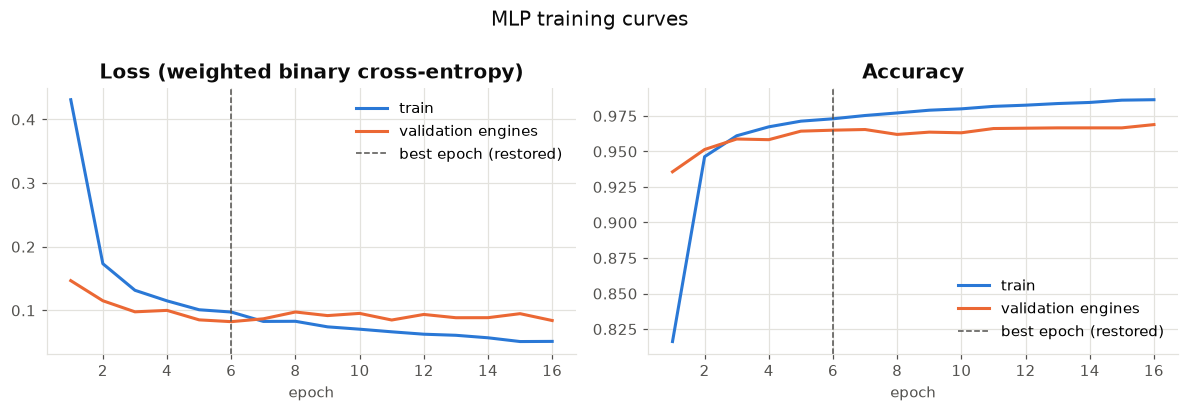

In [26]:
def plot_history(hist, title, fname):
    h = hist.history
    ep = np.arange(1, len(h["loss"]) + 1)
    best = int(np.argmin(h["val_loss"])) + 1
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
    for ax, key, label in [(axes[0], "loss", "Loss (weighted binary cross-entropy)"),
                           (axes[1], "accuracy", "Accuracy")]:
        ax.plot(ep, h[key], color=BLUE, linewidth=2, label="train")
        ax.plot(ep, h[f"val_{key}"], color=ORANGE, linewidth=2, label="validation engines")
        ax.axvline(best, color=INK_SOFT, linestyle="--", linewidth=1, label="best epoch (restored)")
        ax.set_title(label); ax.set_xlabel("epoch"); ax.legend()
    fig.suptitle(title, fontsize=13, y=1.0, color=INK)
    save(fname)
    plt.show()

plot_history(hist_mlp, "MLP training curves", "10_mlp_training_curves")

## 7.2 LSTM — learning the temporal pattern directly

All the models so far share a blind spot: they see **one row at a time**. We made up for this by hand-engineering rolling and drift features, which means we *told* the models about the engine's history.

A **Long Short-Term Memory** network (Hochreiter & Schmidhuber, 1997) is a recurrent network whose gated memory cell carries information across time steps. It reads a **window of 30 consecutive cycles** as a sequence and learns the temporal pattern itself, straight from the **14 raw sensors**, with **no engineered features**. LSTMs are a standard approach for C-MAPSS prognostics (Zheng et al., 2017).

That makes this a real experiment:

> **Do features learned from raw sequences beat hand-crafted temporal features?**

Each window is labelled with the label of its **last** cycle, so window *k* answers the same question as row *k* for the other models, on exactly the same evaluation rows.

In [27]:
def make_sequences(df, sensors, seq_len=SEQ_LEN):
    """Sliding windows within each engine. Returns windows, the label at each window's last
    cycle, and the (unit, cycle) key of that last cycle, used to align with the other models."""
    Xs, ys, keys = [], [], []
    for unit, g in df.sort_values(["unit", "cycle"]).groupby("unit"):
        vals, labs, cyc = g[sensors].to_numpy("float32"), g["label"].to_numpy(), g["cycle"].to_numpy()
        for end in range(seq_len, len(g) + 1):
            Xs.append(vals[end - seq_len:end])
            ys.append(labs[end - 1])
            keys.append((unit, cyc[end - 1]))
    return np.stack(Xs), np.asarray(ys), pd.MultiIndex.from_tuples(keys, names=["unit", "cycle"])

# LSTMs train best on inputs in [0, 1]; fit the scaler on TRAINING engines only
mm = MinMaxScaler().fit(tr[useful])
scaled = lambda df: df.assign(**dict(zip(useful, mm.transform(df[useful]).T)))

X_tr_seq, y_tr_seq, _        = make_sequences(scaled(tr), useful)
X_va_seq, y_va_seq, keys_va  = make_sequences(scaled(va), useful)
X_te_seq, y_te_seq, keys_te  = make_sequences(scaled(te), useful)

# the LSTM's windows must line up one-to-one with the rows the other models are scored on
assert keys_va.equals(pd.MultiIndex.from_frame(va_eval[["unit", "cycle"]])) and (y_va_seq == y_va).all()
assert keys_te.equals(pd.MultiIndex.from_frame(te_eval[["unit", "cycle"]])) and (y_te_seq == y_te).all()

print(f"LSTM input: {X_tr_seq.shape}  ->  (windows, timesteps, sensors)")
print(f"Validation windows: {len(X_va_seq):,} = validation rows scored for every model: {len(X_va):,}")
print(f"Test windows:       {len(X_te_seq):,} = test rows scored for every model:       {len(X_te):,}")

LSTM input: (13394, 30, 14)  ->  (windows, timesteps, sensors)
Validation windows: 4,337 = validation rows scored for every model: 4,337
Test windows:       10,196 = test rows scored for every model:       10,196


In [28]:
keras.utils.set_random_seed(RANDOM_STATE)

lstm = keras.Sequential([
    keras.layers.Input(shape=(SEQ_LEN, len(useful))),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
], name="LSTM")

lstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
             metrics=["accuracy"])
lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
cw_seq = {0: 1.0, 1: float((y_tr_seq == 0).sum() / (y_tr_seq == 1).sum())}

hist_lstm = lstm.fit(X_tr_seq, y_tr_seq, validation_data=(X_va_seq, y_va_seq),
                     epochs=60, batch_size=256, class_weight=cw_seq, verbose=0, shuffle=True,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                                              restore_best_weights=True)])
best_ep = int(np.argmin(hist_lstm.history["val_loss"])) + 1
print(f"Trained {len(hist_lstm.history['loss'])} epochs; best validation loss at epoch {best_ep}.")

evaluate("LSTM", "validation", y_va, lstm.predict(X_va_seq, verbose=0).ravel())

Trained 21 epochs; best validation loss at epoch 13.


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
LSTM — validation,0.9562,0.8183,0.9703,0.8878,0.9938,0.9728


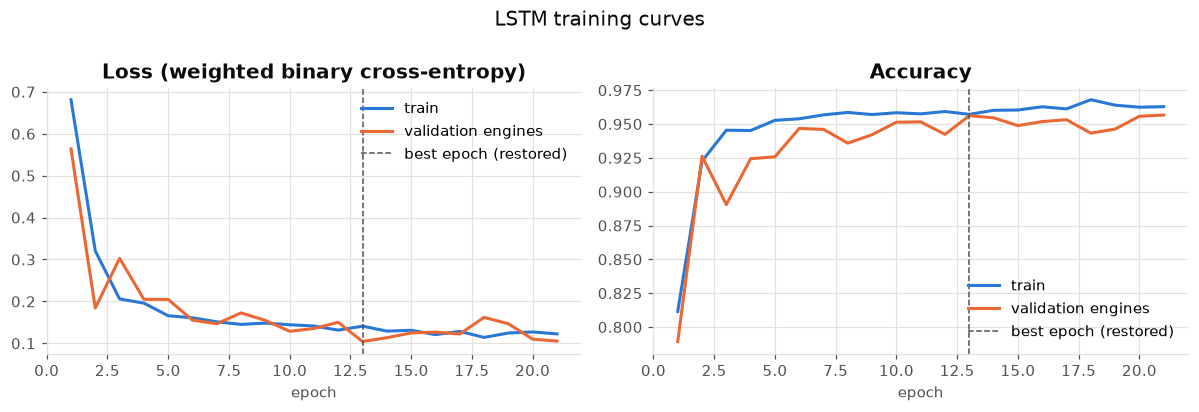

In [30]:
plot_history(hist_lstm, "LSTM training curves", "11_lstm_training_curves")

## 7.3 Validation summary — model selection
All six models, scored on the same 25 validation engines. This table is used to choose between models. The test set has not been touched yet.

In [31]:
val_df = pd.DataFrame(RESULTS["validation"]).T[METRICS]
best_val = val_df.drop("Baseline (majority)")["F1"].idxmax()
print(f"Best validation F1: {best_val}")
val_df.style.format("{:.4f}").background_gradient(cmap="Greens", axis=0)

Best validation F1: Random Forest


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (majority),0.8213,0.0000,0.0000,0.0000,0.5000,0.1787
Decision Tree,0.9294,0.7711,0.8606,0.8134,0.9235,0.7970
Random Forest,0.9680,0.9036,0.9187,0.9111,0.9935,0.9719
Naive Bayes,0.9306,0.7261,0.9819,0.8349,0.9836,0.8800
MLP (ANN),0.9650,0.8643,0.9535,0.9067,0.9951,0.9802
LSTM,0.9562,0.8183,0.9703,0.8878,0.9938,0.9728


---
# 8. Final evaluation on the NASA test set

Every model is now frozen and scored **once** on NASA's 100 separate test engines. None of these engines was used for training, tuning, early stopping or model selection, so this is our honest estimate of how the models would perform on new engines.

**Note on class balance.** NASA stops each test engine at a random point before failure, so far fewer test rows fall in the final 30 cycles than in the run-to-failure validation engines (about 3% versus 18%). With fewer real failures to find, the same false-alarm rate produces lower **precision**, and therefore lower F1, than on validation. ROC-AUC does not depend on class prevalence, so it is the fairest metric to compare between the two sets.

In [32]:
test_probs = {
    "Baseline (majority)": baseline.predict_proba(X_te)[:, 1],
    "Decision Tree":       dt.predict_proba(X_te)[:, 1],
    "Random Forest":       rf.predict_proba(X_te)[:, 1],
    "Naive Bayes":         nb.predict_proba(X_te)[:, 1],
    "MLP (ANN)":           mlp.predict(X_te, verbose=0).ravel(),
    "LSTM":                lstm.predict(X_te_seq, verbose=0).ravel(),
}
for name, prob in test_probs.items():
    evaluate(name, "test", y_te, prob)

test_df = pd.DataFrame(RESULTS["test"]).T[METRICS]
print(f"Test set: {te_eval.unit.nunique()} engines, {len(y_te):,} rows, "
      f"{y_te.sum():,} failure-window rows ({y_te.mean():.1%})")
test_df.style.format("{:.4f}").background_gradient(cmap="Greens", axis=0)

Test set: 100 engines, 10,196 rows, 332 failure-window rows (3.3%)


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (majority),0.9674,0.0000,0.0000,0.0000,0.5000,0.0326
Decision Tree,0.9791,0.6595,0.7410,0.6979,0.8752,0.6299
Random Forest,0.9885,0.8525,0.7831,0.8163,0.9968,0.9150
Naive Bayes,0.9736,0.5574,0.9217,0.6947,0.9925,0.7780
MLP (ANN),0.9859,0.7461,0.8584,0.7983,0.9958,0.9145
LSTM,0.9856,0.7060,0.9548,0.8118,0.9970,0.9241


In [33]:
# ---- full per-class report for every model (test set) ---------------------------------
for name, (yt, yp) in PROBS["test"].items():
    if name.startswith("Baseline"):
        continue
    print(f"=============== {name} ===============")
    print(classification_report(yt, (yp >= 0.5).astype(int), digits=3, zero_division=0,
                                target_names=["Healthy", "Failure within 30"]))

=============== Decision Tree ===============
                   precision    recall  f1-score   support

          Healthy      0.991     0.987     0.989      9864
Failure within 30      0.660     0.741     0.698       332

         accuracy                          0.979     10196
        macro avg      0.825     0.864     0.844     10196
     weighted avg      0.980     0.979     0.980     10196

=============== Random Forest ===============
                   precision    recall  f1-score   support

          Healthy      0.993     0.995     0.994      9864
Failure within 30      0.852     0.783     0.816       332

         accuracy                          0.989     10196
        macro avg      0.923     0.889     0.905     10196
     weighted avg      0.988     0.989     0.988     10196

=============== Naive Bayes ===============
                   precision    recall  f1-score   support

          Healthy      0.997     0.975     0.986      9864
Failure within 30      0.557   

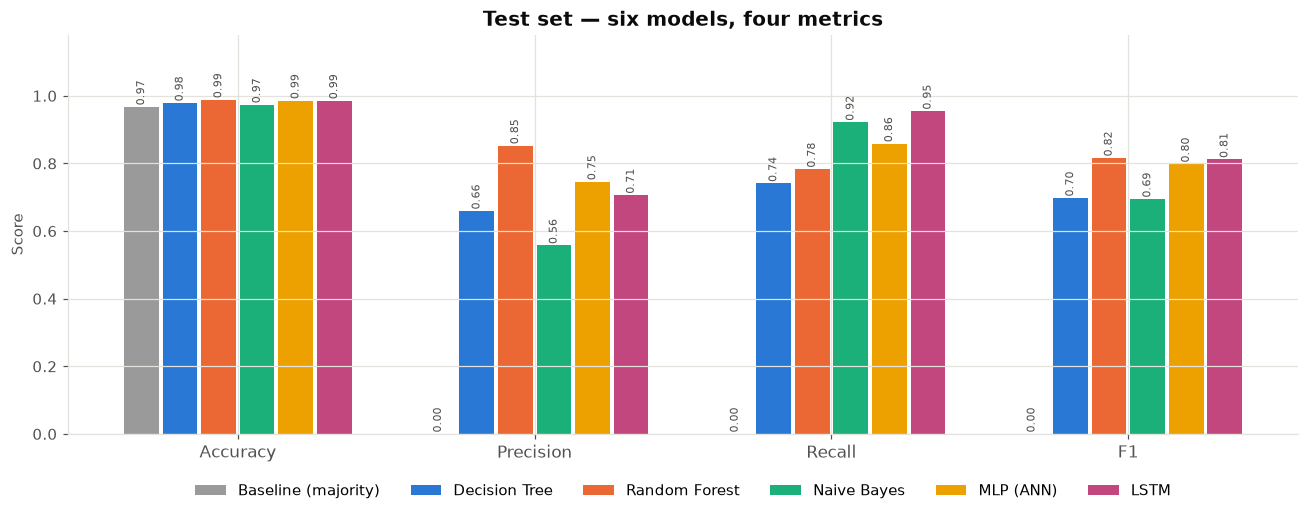

In [34]:
# ---- grouped comparison chart (test set) ----------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1"]
models  = list(test_df.index)
x, w = np.arange(len(metrics)), 0.13

fig, ax = plt.subplots(figsize=(12, 4.8))
for i, m in enumerate(models):
    vals = test_df.loc[m, metrics].values
    bars = ax.bar(x + (i - (len(models) - 1) / 2) * w, vals, w * 0.9, label=m, color=PALETTE[m])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}",
                ha="center", fontsize=7, color=INK_SOFT, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.18); ax.set_ylabel("Score")
ax.set_title("Test set — six models, four metrics")
ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.09))
save("12_model_comparison")
plt.show()

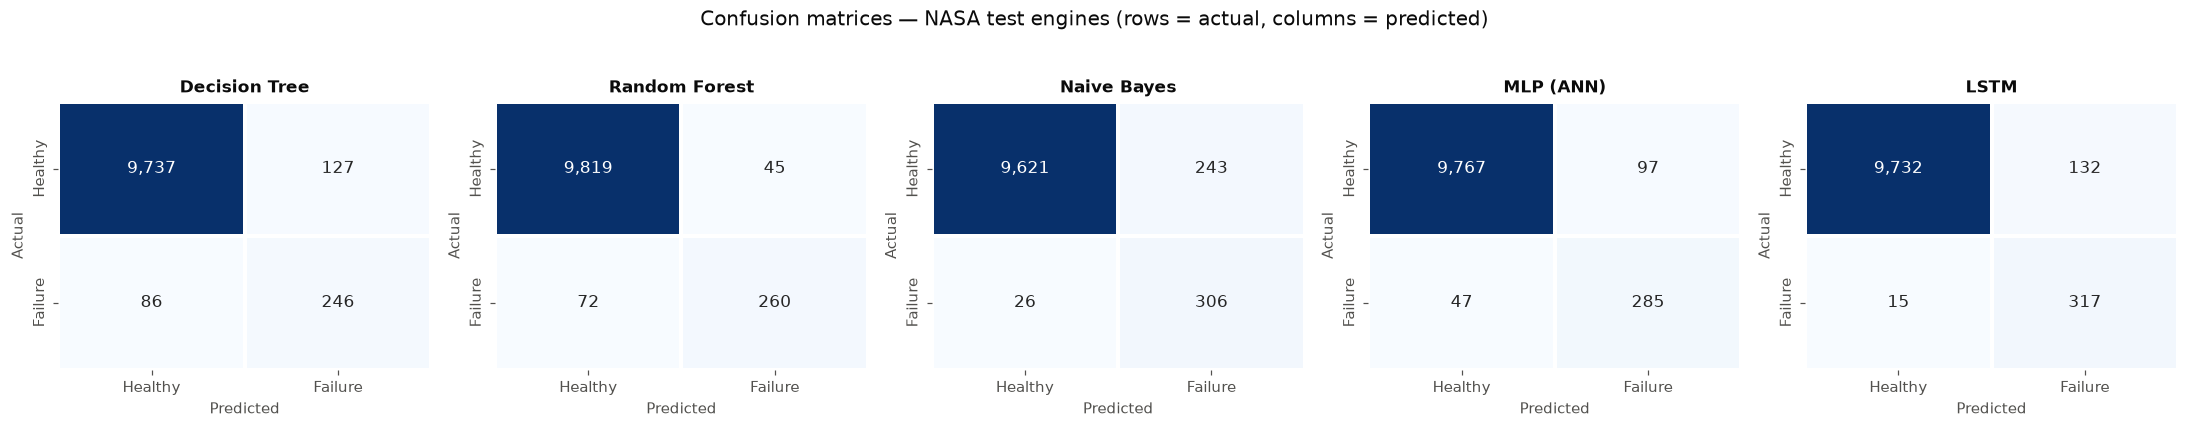

In [35]:
# ---- confusion matrices for the five real models (test set) ---------------------------
real_models = [m for m in models if not m.startswith("Baseline")]
fig, axes = plt.subplots(1, 5, figsize=(20, 3.7))
for ax, name in zip(axes, real_models):
    plot_confusion(name, "test", ax)
fig.suptitle("Confusion matrices — NASA test engines (rows = actual, columns = predicted)",
             fontsize=13, y=1.04, color=INK)
save("13_confusion_all")
plt.show()

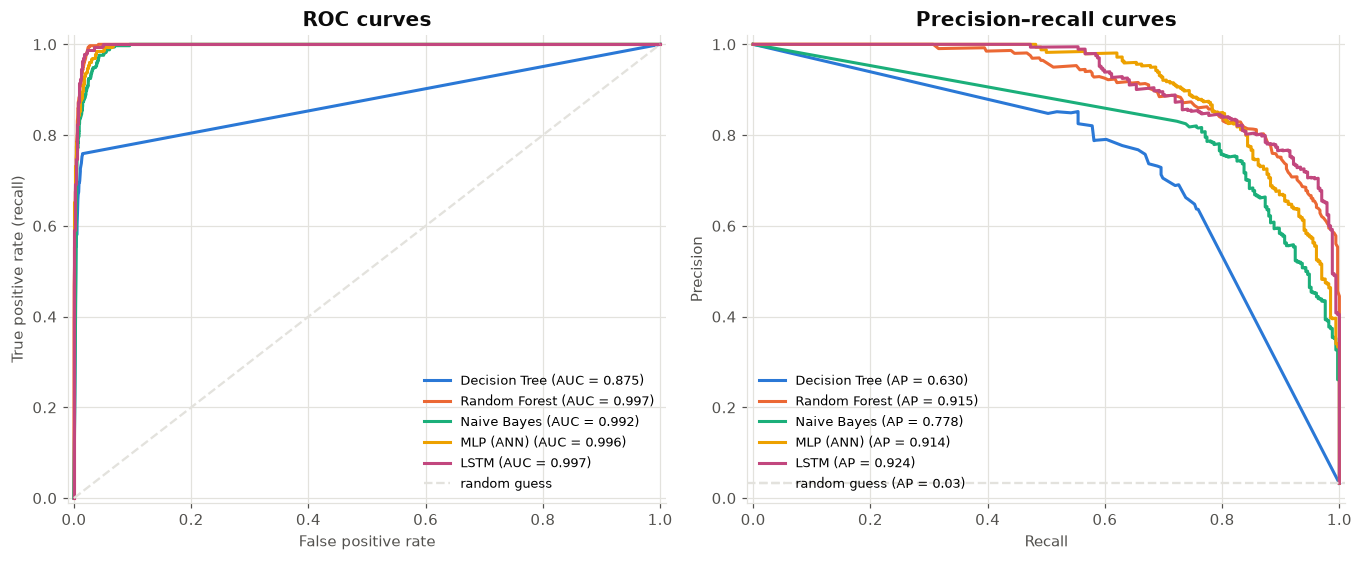

In [36]:
# ---- ROC and precision-recall curves (test set) ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
for name in real_models:
    yt, yp = PROBS["test"][name]
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, color=PALETTE[name], linewidth=2,
                 label=f"{name} (AUC = {RESULTS['test'][name]['ROC-AUC']:.3f})")
    prec, rec, _ = precision_recall_curve(yt, yp)
    axes[1].plot(rec, prec, color=PALETTE[name], linewidth=2,
                 label=f"{name} (AP = {RESULTS['test'][name]['PR-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color=GRID, linewidth=1.5, label="random guess")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curves")
axes[1].axhline(y_te.mean(), linestyle="--", color=GRID, linewidth=1.5,
                label=f"random guess (AP = {y_te.mean():.2f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curves")
for ax in axes:
    ax.legend(loc="lower right" if ax is axes[0] else "lower left", fontsize=8.5)
    ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.02)
save("14_roc_pr_curves")
plt.show()

**Reading the curves.** ROC-AUC measures how well each model *ranks* failing rows above healthy ones, at every possible threshold. The precision–recall curve is more informative under class imbalance. It shows the price in false alarms of catching more failures. A maintenance planner can choose any operating point on these curves by moving the 0.5 threshold.

## 8.1 Decision at the last observed cycle
The row-level scores above count every cycle. In practice, a planner looks at each engine **as it is now** and decides whether to schedule maintenance. For each of the 100 test engines we take the prediction at its **last observed cycle**, which is exactly the point where NASA supplies the true remaining life.

In [37]:
last_mask = (te_eval.groupby("unit")["cycle"].transform("max") == te_eval["cycle"]).to_numpy()
y_last = y_te[last_mask]
print(f"{last_mask.sum()} test engines; {y_last.sum()} of them are within {W} cycles of failure "
      f"at their last observed cycle.\n")

last_rows = {}
for name in real_models:
    p = test_probs[name][last_mask]
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_last, pred, labels=[0, 1]).ravel()
    last_rows[name] = {"Caught (TP)": tp, "Missed (FN)": fn, "False alarms (FP)": fp,
                       "Recall": recall_score(y_last, pred, zero_division=0),
                       "Precision": precision_score(y_last, pred, zero_division=0),
                       "F1": f1_score(y_last, pred, zero_division=0)}
last_df = pd.DataFrame(last_rows).T
last_df.style.format({"Recall": "{:.3f}", "Precision": "{:.3f}", "F1": "{:.3f}",
                      "Caught (TP)": "{:.0f}", "Missed (FN)": "{:.0f}", "False alarms (FP)": "{:.0f}"})

100 test engines; 25 of them are within 30 cycles of failure at their last observed cycle.



,Caught (TP),Missed (FN),False alarms (FP),Recall,Precision,F1
Decision Tree,22,3,4,0.880,0.846,0.863
Random Forest,22,3,3,0.880,0.880,0.880
Naive Bayes,24,1,4,0.960,0.857,0.906
MLP (ANN),24,1,2,0.960,0.923,0.941
LSTM,25,0,2,1.000,0.926,0.962


In [38]:
# ---- validation vs test: do the rankings hold up on unseen engines? ---------------------
gen = pd.DataFrame({"F1 validation": val_df["F1"], "F1 test": test_df["F1"],
                    "ROC-AUC validation": val_df["ROC-AUC"], "ROC-AUC test": test_df["ROC-AUC"]})
gen.round(4)

,F1 validation,F1 test,ROC-AUC validation,ROC-AUC test
Baseline (majority),0.0000,0.0000,0.5000,0.5000
Decision Tree,0.8134,0.6979,0.9235,0.8752
Random Forest,0.9111,0.8163,0.9935,0.9968
Naive Bayes,0.8349,0.6947,0.9836,0.9925
MLP (ANN),0.9067,0.7983,0.9951,0.9958
LSTM,0.8878,0.8118,0.9938,0.9970


In [39]:
# ---- export results -------------------------------------------------------------------
results_all = pd.concat({"validation": val_df, "test": test_df}, names=["split", "model"]).round(4)
results_all.to_csv("model_comparison.csv")
last_df.round(4).to_csv("model_comparison_last_cycle.csv")

print("Saved model_comparison.csv and model_comparison_last_cycle.csv")
print(f"Saved {len(os.listdir(FIGDIR))} figures to ./{FIGDIR}/:")
for f in sorted(os.listdir(FIGDIR)):
    print("  ", f)

Saved model_comparison.csv and model_comparison_last_cycle.csv
Saved 14 figures to ./figures/:
   01_engine_lifetimes.png
   02_sensor_variability.png
   03_degradation_trajectories.png
   04_class_balance.png
   05_sensor_rul_correlation.png
   06_sensor_correlation_matrix.png
   07_decision_tree_top.png
   08_rf_feature_importance.png
   09_confusion_classical.png
   10_mlp_training_curves.png
   11_lstm_training_curves.png
   12_model_comparison.png
   13_confusion_all.png
   14_roc_pr_curves.png


---
# 9. Conclusion

All numbers below come from the **NASA test set**: 100 unseen engines and 10,196 rows scored identically for every model. The tables in Section 8 show them in full.

| Model | Precision | Recall | F1 | ROC-AUC | Imminent engines caught at last cycle (of 25) | False alarms at last cycle |
|---|---|---|---|---|---|---|
| Baseline (majority) | 0.000 | 0.000 | 0.000 | 0.500 | — | — |
| Decision Tree | 0.660 | 0.741 | 0.698 | 0.875 | 22 | 4 |
| **Random Forest** | **0.853** | 0.783 | **0.816** | 0.997 | 22 | 3 |
| Naïve Bayes | 0.557 | 0.922 | 0.695 | 0.992 | 24 | 4 |
| MLP (ANN) | 0.746 | 0.858 | 0.798 | 0.996 | 24 | 2 |
| **LSTM** | 0.706 | **0.955** | 0.812 | **0.997** | **25** | 2 |

**1. Accuracy cannot separate the models, but recall and precision can.** Always predicting "healthy" scores 96.7% test accuracy while catching no failures at all. Every real model sits between 97.4% and 98.9%. The differences that matter show up in precision and recall, which is why we led with them.

**2. There is no single winner. The best model depends on what a missed failure costs.**
- **Random Forest** has the best F1 (0.816) and by far the best precision (0.853): only 45 false-alarm rows, against 97–243 for the other models. It also had the best validation F1, so our model-selection step held up on unseen engines. It is the right choice when unnecessary inspections are expensive.
- **LSTM** has the best recall (0.955) and the joint-best ROC-AUC (0.997). At each test engine's last observed cycle it flagged **all 25 engines** that were really within 30 cycles of failure, with only 2 false alarms. In aviation, a missed failure costs far more than an extra inspection, so this is our recommended operating model.
- **MLP** sits between the two on precision and recall (F1 0.798). It clearly improves on the single tree, but the Random Forest beat it on the same engineered features.

The high ROC-AUC values (≥ 0.99 for RF, NB, MLP and LSTM) show that these models *rank* engines almost perfectly. So the precision–recall balance can be tuned by moving the decision threshold to match an airline's real cost ratio.

**3. Feature engineering is what made the row-based models work.** Engineered rolling-mean, rolling-std and drift features supply **82%** of the Random Forest's total importance and **11 of its top 15** features. They make up 42 of the 57 features, so this share is well above what their number alone would suggest. The forest leans on engine *history*, not on single readings.

**4. The LSTM experiment: learned temporal features match hand-crafted ones.** With only the 14 raw sensors and no engineered features at all, the LSTM matched the Random Forest on F1 (0.812 vs 0.816) and ROC-AUC (0.997 vs 0.997), and caught more failures. Two conclusions follow. First, sequence models can learn the degradation pattern themselves. Second, our hand-crafted features captured most of the available temporal signal. The LSTM costs more to train, but it needs no domain-specific feature design.

**5. Naïve Bayes failed in the way its assumptions predicted.** The sensors are strongly inter-correlated: the mean |r| is 0.58, and 38 of 91 pairs have |r| > 0.7. Naïve Bayes treats each sensor as independent evidence, so it counts the same degradation signal many times over. The result is extreme over-confidence: **98%** of its validation probabilities are below 1% or above 99%, against 64% for the Random Forest. On the test set, that over-confidence produces high recall (0.922) but the most false alarms (243 rows) and the lowest precision (0.557). Its ROC-AUC is still high (0.992), which shows that the *ranking* of engines is sound but the *probabilities* are badly calibrated.

**6. A single Decision Tree is interpretable but unstable.** It gives readable maintenance rules (Section 6.2). However, it had the largest drop in F1 from validation to test (0.813 → 0.698) and the lowest ROC-AUC (0.875). This is exactly the instability that the Random Forest's bagging is designed to fix.